# Daily Births Forecasting

The goal is to forecast the number of daily female births in California. The data is a well-known time series with one value per day for the year 1959 (365 values, `daily-total-female-births.csv`).

Reference solution: [Daily Births Forecasting with Machine Learning](https://amanxai.com/2020/08/27/daily-births-forecasting-with-machine-learning/) (Aman Kharwal). Dataset: [daily-total-female-births.csv](https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-total-female-births.csv).

The reference fits a Facebook Prophet model with yearly seasonality, a very flexible trend and multiplicative seasonality on the whole year, forecasts 50 more days and shows the plots. It never compares the forecast with real values, and it does not compare Prophet with a simple model. Tools used here: the seasonal decomposition, SARIMAX and Prophet.

In [1]:
#pip install prophet

In [2]:
#pip install statsmodels

In [3]:
import logging
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Time Series/daily_births_forecasting')
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

Importing plotly failed. Interactive plots will not work.


## Data Loading

In [4]:
df = pd.read_csv("daily-total-female-births.csv", parse_dates=["Date"], index_col="Date")
print(df.shape, "| null values:", df["Births"].isnull().sum(), "| days without a gap:", (df.index.to_series().diff().dt.days.dropna() == 1).all())
df["Births"].describe().round(1)

(365, 1) | null values: 0 | days without a gap: True


count    365.0
mean      42.0
std        7.3
min       23.0
25%       37.0
50%       42.0
75%       46.0
max       73.0
Name: Births, dtype: float64

## Exploratory Data Analysis

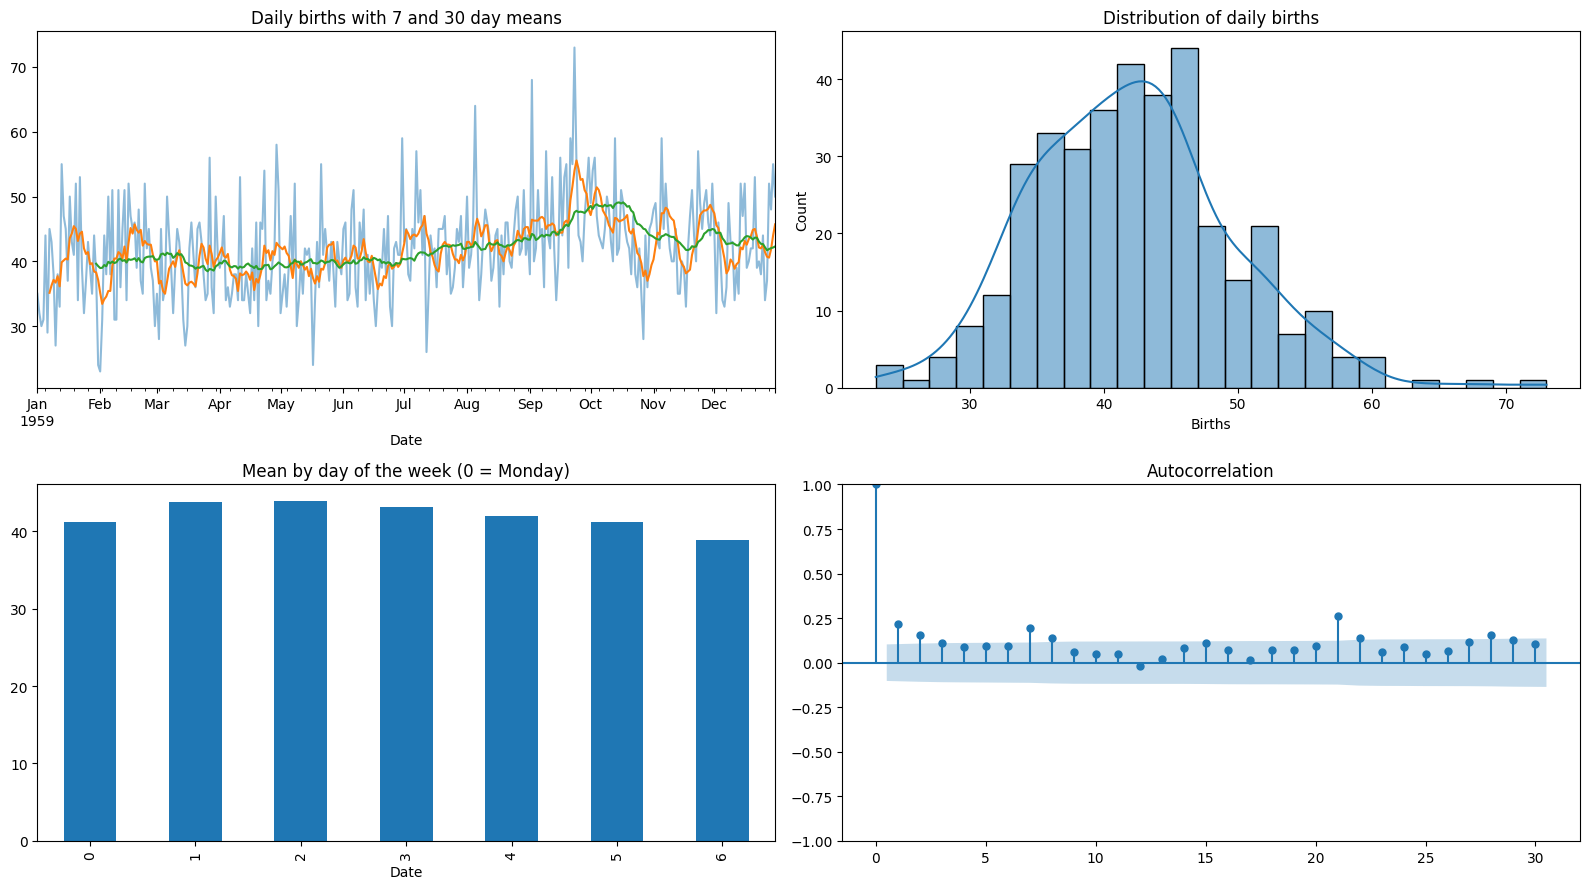

outliers above 3 standard deviations: {Timestamp('1959-09-02 00:00:00'): 68, Timestamp('1959-09-23 00:00:00'): 73}
{1: 39.1, 2: 41.0, 3: 39.3, 4: 39.8, 5: 39.0, 6: 40.4, 7: 41.9, 8: 43.6, 9: 48.2, 10: 44.1, 11: 45.0, 12: 42.4}


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
df["Births"].plot(ax=axes[0, 0], alpha=0.5, title="Daily births with 7 and 30 day means")
df["Births"].rolling(7).mean().plot(ax=axes[0, 0]); df["Births"].rolling(30).mean().plot(ax=axes[0, 0])
sns.histplot(df["Births"], bins=25, kde=True, ax=axes[0, 1]).set_title("Distribution of daily births")
df.groupby(df.index.dayofweek)["Births"].mean().plot(kind="bar", ax=axes[1, 0], title="Mean by day of the week (0 = Monday)")
plot_acf(df["Births"], lags=30, ax=axes[1, 1])
plt.tight_layout(); plt.show()

print("outliers above 3 standard deviations:", df[df["Births"] > df["Births"].mean() + 3 * df["Births"].std()]["Births"].to_dict())
print(df.groupby(df.index.month)["Births"].mean().round(1).to_dict())

The series moves around a mean of 42 births per day with a standard deviation of 7.3, without gaps or missing values. Two days are more than three standard deviations above the mean (68 births on 2 September and 73 on 23 September); they look like real peaks and are kept. The monthly means rise from 39 in January to 48 in September and fall back to 42 in December, which could be a yearly pattern or a slow drift, but a single year of data cannot tell the two apart. The day of the week matters little (means from 38.9 on Sunday to 43.8 on Tuesday and Wednesday), and the autocorrelation is weak (0.22 for one day, 0.20 for seven days).

## Seasonal Decomposition

The decomposition splits the series into a trend, a weekly seasonal part and a remainder. The share of the variance of the series that each part carries shows how much structure there is to forecast.

In [6]:
decomposition = seasonal_decompose(df["Births"], model="additive", period=7)
parts = pd.DataFrame({"trend": decomposition.trend, "seasonal (weekly)": decomposition.seasonal, "remainder": decomposition.resid}).dropna()
(parts.var() / df["Births"].loc[parts.index].var()).round(3)

trend                0.264
seasonal (weekly)    0.047
remainder            0.673
dtype: float64

## Reference Reproduction

The reference model is fitted on the whole year with its parameters (yearly seasonality, `changepoint_range=0.9`, `changepoint_prior_scale=0.5`, multiplicative seasonality) and the next 50 days are forecast. The fit and the forecast are shown, but they are not compared with anything.

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
16:48:23 - cmdstanpy - INFO - Chain [1] start processing
16:48:23 - cmdstanpy - INFO - Chain [1] done processing


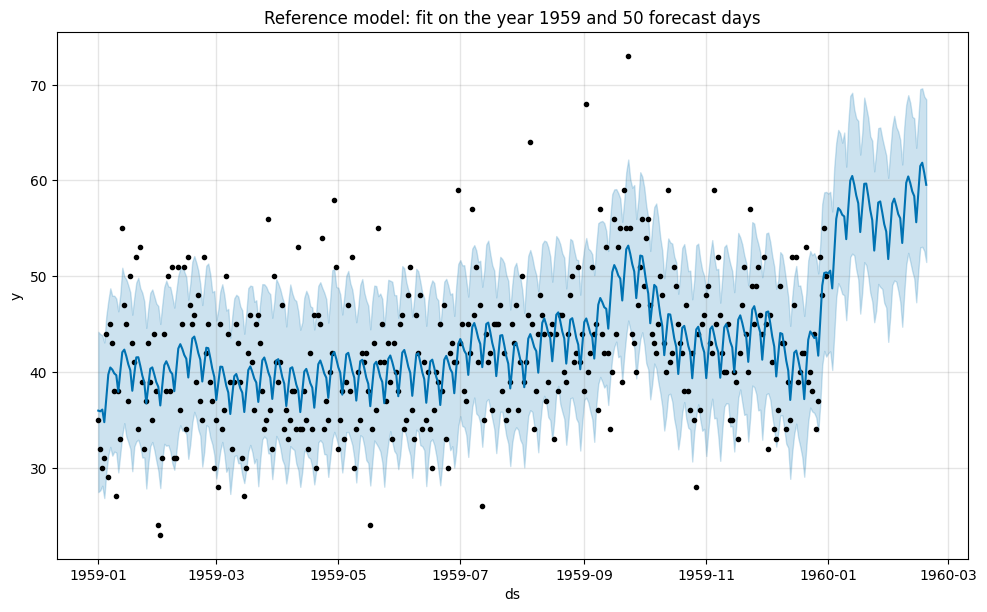

in-sample RMSE of the reference model: 6.48
forecast for the last day of the year, 25 days later and 50 days later: [50.4, 55.2, 59.5]


In [7]:
prophet_data = df.reset_index().rename(columns={"Date": "ds", "Births": "y"})
reference = Prophet(yearly_seasonality=True, daily_seasonality=False, changepoint_range=0.9, changepoint_prior_scale=0.5, seasonality_mode="multiplicative")
reference.fit(prophet_data)
forecast = reference.predict(reference.make_future_dataframe(periods=50, freq="d"))

reference.plot(forecast)
plt.title("Reference model: fit on the year 1959 and 50 forecast days")
plt.show()
print("in-sample RMSE of the reference model:", round(np.sqrt(mean_squared_error(prophet_data["y"], forecast["yhat"][:365])), 2))
print("forecast for the last day of the year, 25 days later and 50 days later:", forecast["yhat"].iloc[[364, 389, 414]].round(1).tolist())

The reference model fits the year with an error (RMSE 6.5) hardly below the standard deviation of the data itself (7.3): it explains very little, although it has many parameters. Prophet also warns that yearly seasonality needs about two years of data ("less than 730 days"), and the reference has 365 days. Its forecast for the next 50 days climbs from 50.5 on the last day of the year to 59.8 fifty days later, which is 42% above the yearly mean and is not credible, but the article has no true values to show it. The next part makes that test possible.

## Model Training

To find out whether a forecast is any good, the last part of the series has to be kept away from the models. Six forecasts of 30 days are made with an expanding training window (a rolling origin: the training data ends on day 185, 215, ..., 335, and the next 30 days are forecast). Six models are compared:

- **mean of the past:** the mean of all the training days.
- **last value:** the last observed day, repeated (the naive forecast).
- **mean of the last 7 days.**
- **ARIMA:** `SARIMAX` without seasonality; the orders (p, d, q) are chosen with the AIC on the first training window.
- **Prophet, reference settings:** with yearly seasonality and the flexible trend.
- **Prophet, default settings:** with the weekly seasonality that Prophet decides on its own.

In [8]:
first_window = df["Births"][:185]
aic = {(p, d, q): SARIMAX(first_window, order=(p, d, q)).fit(disp=False).aic for p in range(3) for d in range(2) for q in range(3) if (p, d, q) != (0, 0, 0)}
best_order = min(aic, key=aic.get)
print("order chosen with the AIC:", best_order, "| AIC:", round(aic[best_order], 1))

order chosen with the AIC: (0, 1, 1) | AIC: 1247.1


In [9]:
def prophet_forecast(train, **settings):
    model = Prophet(daily_seasonality=False, **settings).fit(train.reset_index().rename(columns={"Date": "ds", "Births": "y"}))
    return model.predict(pd.DataFrame({"ds": pd.date_range(train.index[-1] + pd.Timedelta(days=1), periods=30)}))["yhat"].values

methods = {
    "mean of the past": lambda train: np.repeat(train["Births"].mean(), 30),
    "last value": lambda train: np.repeat(train["Births"].iloc[-1], 30),
    "mean of the last 7 days": lambda train: np.repeat(train["Births"].iloc[-7:].mean(), 30),
    f"ARIMA{best_order}": lambda train: SARIMAX(train["Births"], order=best_order).fit(disp=False).forecast(30).values,
    "Prophet, reference settings": lambda train: prophet_forecast(train, yearly_seasonality=True, changepoint_range=0.9, changepoint_prior_scale=0.5, seasonality_mode="multiplicative"),
    "Prophet, default settings": lambda train: prophet_forecast(train),
}

origins = [185, 215, 245, 275, 305, 335]
actual = {origin: df["Births"].iloc[origin:origin + 30].values for origin in origins}
forecasts = {name: {origin: method(df.iloc[:origin]) for origin in origins} for name, method in methods.items()}

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
16:48:26 - cmdstanpy - INFO - Chain [1] start processing
16:48:26 - cmdstanpy - INFO - Chain [1] done processing
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
16:48:26 - cmdstanpy - INFO - Chain [1] start processing
16:48:26 - cmdstanpy - INFO - Chain [1] done processing
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent o

## Evaluation

In [10]:
def scores(name):
    errors = [(mean_absolute_error(actual[o], forecasts[name][o]), np.sqrt(mean_squared_error(actual[o], forecasts[name][o]))) for o in origins]
    return {"MAE": np.mean([e[0] for e in errors]), "RMSE": np.mean([e[1] for e in errors])}

pd.DataFrame({name: scores(name) for name in methods}).T.sort_values("RMSE").round(2)

,MAE,RMSE
"ARIMA(0, 1, 1)",5.85,7.51
"Prophet, default settings",5.86,7.52
mean of the last 7 days,5.98,7.58
mean of the past,5.85,7.62
last value,9.11,10.52
"Prophet, reference settings",40.07,47.85


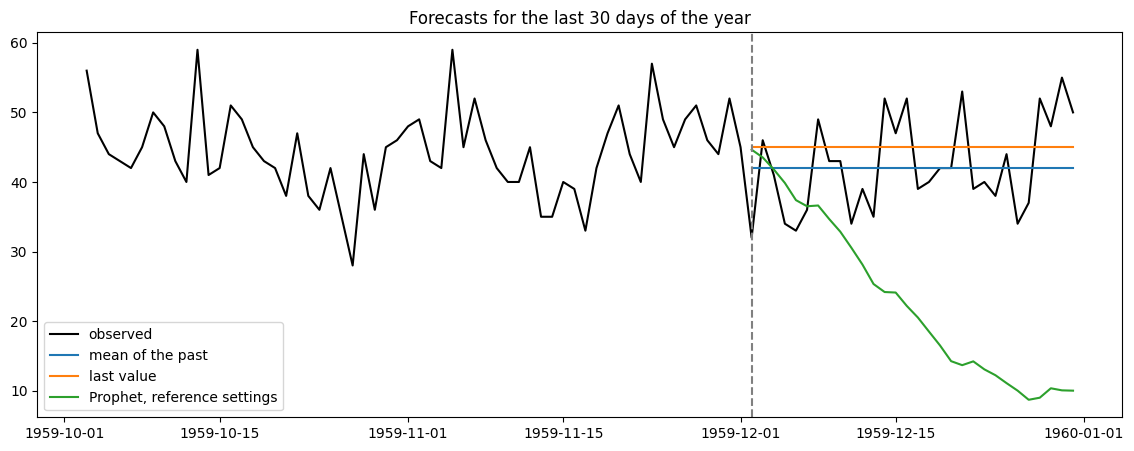

In [11]:
last = origins[-1]
plt.figure(figsize=(14, 5))
plt.plot(df.index[last - 60:last + 30], df["Births"].iloc[last - 60:last + 30], color="black", label="observed")
for name in ["mean of the past", "last value", "Prophet, reference settings"]:
    plt.plot(df.index[last:last + 30], forecasts[name][last], label=name)
plt.axvline(df.index[last], color="grey", linestyle="--")
plt.legend(); plt.title("Forecasts for the last 30 days of the year"); plt.show()

The seasonal decomposition shows why the series is hard to forecast: the weekly seasonal part carries only 4.7% of the variance, the trend 26%, and 67% is remainder, that is, day-to-day noise that no model can predict.

The results of the rolling-origin test confirm it. The four simple or classical forecasts are practically equal: ARIMA(0, 1, 1) has an RMSE of 7.51, Prophet with its default settings 7.52, the mean of the last 7 days 7.58 and the mean of all the past days 7.62. The difference between them (0.1) is much smaller than the spread between the six forecast windows, so none of them can be called better; the best forecast is essentially "a level around the recent mean", and the constant mean of the past is as good as ARIMA. The last value repeated is clearly worse (RMSE 10.5), because a single noisy day is a bad estimate of the level.

The Prophet configuration of the reference is by far the worst: its RMSE is 42.8 and its MAE 36, against about 7.5 and 5.9 for the other models. In the three windows that were checked in detail, its forecasts fall from about 40 to 50 births per day at the start of the window to between 3 and 10 at the end. The combination of yearly seasonality on less than two years of data, a trend that may change at 90% of the data and a large flexibility (`changepoint_prior_scale=0.5`) extrapolates the last segment of the trend far beyond the data. The fit on the training year looks fine (RMSE 6.5), which is why looking at the in-sample plot, as the reference does, does not reveal the problem.

## Conclusion

**Reference approach.** The reference fits a Prophet model with yearly seasonality, `changepoint_range=0.9`, `changepoint_prior_scale=0.5` and multiplicative seasonality on the whole year of 1959, forecasts 50 days and looks at the plots. There is no held-out data and no comparison with a simple model. With 365 days, Prophet itself warns that yearly seasonality is under-identified.

**Findings.** The series is mostly noise: around a mean of 42 births per day (standard deviation 7.3), the weekly pattern explains 4.7% of the variance, the trend 26% and the remainder 67%. The reference model fits the year with an RMSE of 6.5, barely below the standard deviation, and forecasts a rise to 59.8 births per day after 50 days.

**Our approach.** Six forecasts of 30 days with an expanding training window (training data ending on day 185, 215, 245, 275, 305 and 335) were made with six methods, and the errors were averaged:

| Method | MAE | RMSE |
|---|---|---|
| ARIMA(0, 1, 1) (order chosen with the AIC) | 5.85 | 7.51 |
| Prophet, default settings | 5.86 | 7.52 |
| Mean of the last 7 days | 5.98 | 7.58 |
| Mean of the past | 5.85 | 7.62 |
| Last value | 9.11 | 10.52 |
| Prophet, reference settings | 35.96 | 42.81 |

A constant forecast at the level of the past mean is as good as ARIMA and Prophet with default settings; there is no structure in the data that a complex model could use. The Prophet settings of the reference are dangerous: an error five times larger than the others, with forecasts that fall towards zero in the windows checked.

**Limitations.** One year of data is short: a yearly seasonality (the rise in September) cannot be tested. The six test windows overlap in time and share most of their training data, so the results are correlated; the differences of 0.1 between the four good methods are not significant. The models were not tuned beyond the AIC choice of the ARIMA order, and the reference values (parameters) were used as in the article.